In [1]:
import os
import time
import torch
import numpy as np
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import datasets, models, transforms
from sklearn.metrics import confusion_matrix
from sklearn.metrics import recall_score
from torch.utils.data import ConcatDataset
from sklearn.model_selection import train_test_split

# 记录开始时间
start_time = time.time()

# 定义超参数
batch_size = 64
learning_rate = 0.001
num_epochs = 100

data_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 加载数据集
data_dir = 'C:/Users/WHS/Desktop/SVM-Image-Classification-master/images4'
image_datasets = datasets.ImageFolder(data_dir, data_transforms)

# 划分训练集和测试集
train_data, test_data = train_test_split(image_datasets, test_size=0.3, random_state=42)

dataloaders = {'train':torch.utils.data.DataLoader(train_data, batch_size=64, shuffle=True, num_workers=4),
               'val':torch.utils.data.DataLoader(test_data, batch_size=64, shuffle=False, num_workers=4)}
dataset_sizes = {'train': len(train_data),'val': len(test_data)}

In [3]:
model = models.alexnet(pretrained=True)
num_ftrs = model.classifier[6].in_features
model.classifier[6] = nn.Linear(num_ftrs, 4)
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
model = model.to(device)


# 定义损失函数和优化器
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), 
                      lr=learning_rate, momentum=0.9)

# 训练模型
result = {
          "acu_train": [],
          "acu_test": [],
          "loss_train":[],
          "recall": []
          }
for epoch in range(num_epochs):
    for phase in ['train', 'val']:
        if phase == 'train':
            model.train()
        else:
            model.eval()

        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in dataloaders[phase]:
            
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                if phase == 'train':
                    loss.backward()
                    optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / dataset_sizes[phase]
        epoch_acc = running_corrects.double() / dataset_sizes[phase]
        
        if phase=='train':
            result["acu_train"].append('{:.4f}'.format(epoch_acc))
            result["loss_train"].append('{:.4f}'.format(epoch_loss))
        elif phase=='val':
            result["acu_test"].append('{:.4f}'.format(epoch_acc))
            recall = recall_score(labels.data.detach().cpu().numpy(), preds.detach().cpu().numpy(), average="macro")
            result["recall"].append(recall)

        print('epoch: {}, {} Loss: {:.4f} Acc: {:.4f}'.format(epoch, phase, epoch_loss, epoch_acc))
        with open('C:/Users/WHS/Desktop/Dual-ResNet18-SVM/result/result_file_alexnet.txt', "a") as file:
            file.write('epoch: {}, {} Loss: {:.4f} Acc: {:.4f}\n'.format(epoch, phase, epoch_loss, epoch_acc))

AttributeError: 'int' object has no attribute 'backward'

In [3]:
# 记录结束时间
end_time = time.time()

# 计算算法运行时间
execution_time = end_time - start_time
print(execution_time)

302.3115203380585


In [4]:
torch.save(model.state_dict(), 'alexnet.pth')

In [1]:
import os
import time
import torch
import numpy as np
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import datasets, models, transforms
from sklearn.metrics import confusion_matrix
from sklearn.metrics import recall_score
from torch.utils.data import ConcatDataset
from sklearn.model_selection import train_test_split
start_time = time.time()
data_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
# 加载数据集
data_dir = 'C:/Users/WHS/Desktop/SVM-Image-Classification-master/images3'
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms) for x in ['train', 'val']}
test_loader = torch.utils.data.DataLoader(image_datasets['val'], batch_size=64, shuffle=True, num_workers=4)

model = models.alexnet()
num_ftrs = model.classifier[6].in_features
model.classifier[6] = nn.Linear(num_ftrs, 4)
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

# 加载之前保存的模型参数
model.load_state_dict(torch.load('alexnet.pth'))


for inputs, labels in test_loader:    
    inputs = inputs.to(device)
    labels = labels.to(device)
    outputs = model(inputs)
    _, preds = torch.max(outputs, 1)
    print(labels,preds)
    break
# 记录结束时间
end_time = time.time()

# 计算算法运行时间
execution_time = end_time - start_time
print(execution_time/len(labels))

tensor([3, 0, 2, 2, 2, 1, 0, 2, 0, 3, 2, 1, 1, 0, 1, 1, 1, 1, 2, 3, 0, 3, 0, 3,
        0, 3, 1, 1, 0, 0, 2, 3, 3, 2, 0, 3, 1, 2, 2, 1, 1, 2, 0, 3, 1, 0, 0, 2,
        0, 2, 2, 3, 2, 3, 2, 2, 2, 1, 1, 3, 3, 0, 2, 1], device='cuda:0') tensor([0, 0, 2, 2, 2, 0, 0, 2, 0, 0, 2, 1, 1, 0, 1, 1, 1, 1, 2, 3, 0, 1, 0, 3,
        0, 0, 1, 1, 0, 0, 2, 3, 3, 2, 0, 3, 1, 2, 2, 0, 1, 2, 0, 3, 1, 0, 0, 2,
        0, 2, 2, 3, 2, 0, 2, 2, 2, 1, 1, 3, 3, 0, 2, 1], device='cuda:0')
0.31124215945601463


In [5]:
import matplotlib
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix


"""Use this method directly - """
import itertools
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    matplotlib.rcParams['font.size'] = 18
    matplotlib.rcParams['font.family'] = 'Times New Roman'
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    fig = plt.gcf()
    fig.set_size_inches(5, 4)
    fig.subplots_adjust(left=0.2, bottom=0.2)
    fig.savefig('alexnet_con.png', dpi=300)
    plt.tight_layout()

In [6]:
labels = labels.cpu()
preds = preds.cpu()
cnf_matrix = confusion_matrix(labels.data, preds)
print(cnf_matrix)

[[15  0  0  0]
 [ 2 14  0  0]
 [ 0  0 19  0]
 [ 4  1  0  9]]


Normalized confusion matrix
[[1.         0.         0.         0.        ]
 [0.125      0.875      0.         0.        ]
 [0.         0.         1.         0.        ]
 [0.28571429 0.07142857 0.         0.64285714]]


<ipython-input-5-f48bffe6e09b>:46: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations. 
  plt.tight_layout()


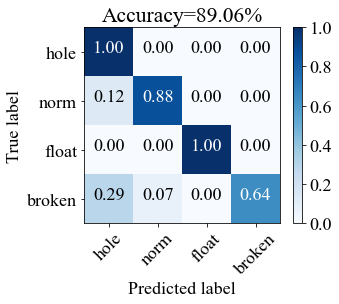

In [7]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(labels.data, preds)
plt.figure()
plot_confusion_matrix(cnf_matrix, ['hole','norm','float','broken'],normalize=True,title='Accuracy={:.2f}%'.format(accuracy*100),cmap=plt.cm.Blues)